# Car Price Analysis Project
## Machine Learning Assignment 1

**Import libraries**

In [222]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [223]:
df = pd.read_csv("../data/car_price.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


# Task 1: Exploratory Data Analysis

In [224]:
# shape of dataset (How many rows and columns does the dataset have?)

df.shape

(72435, 10)

In [225]:
#  Data Types and

df.dtypes

model               str
year            float64
price           float64
transmission        str
mileage         float64
fuelType            str
tax             float64
mpg             float64
engineSize      float64
Make                str
dtype: object

In [226]:
#  Feature Classification (Which features are numerical? Which are categorical? )

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize'], dtype='str')
Categorical Columns: Index(['model', 'transmission', 'fuelType', 'Make'], dtype='str')


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22896\3807493698.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [227]:
#Missing Values (Are there any missing values? How many, and in which columns?)

df.isnull().sum()

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64

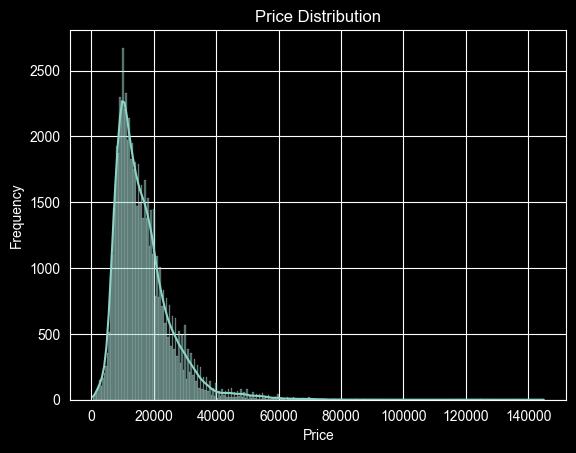

count     68814.000000
mean      16583.919261
std        9304.412707
min         495.000000
25%       10167.250000
50%       14495.000000
75%       20359.750000
max      145000.000000
Name: price, dtype: float64


In [228]:
#Price Distribution ( What does the distribution of car prices look like? )

sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

print(df['price'].describe())

The distribution is right-skewed, meaning most cars are low-priced with few expensive ones

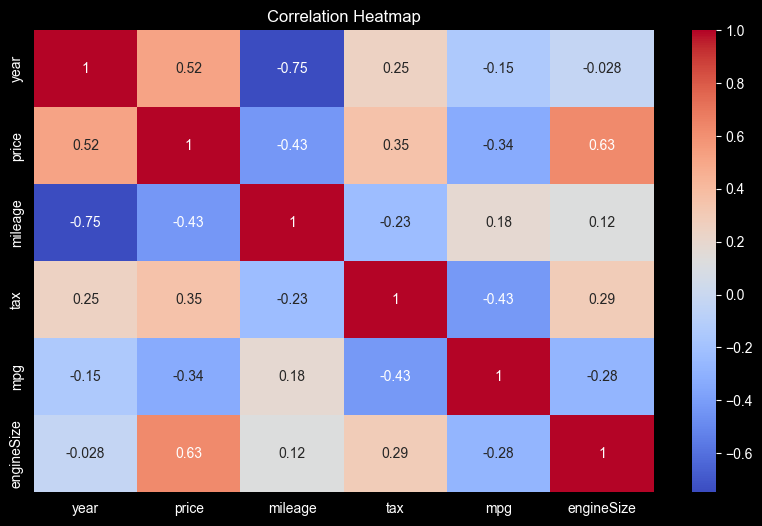

In [229]:
# Correlation Between Features (Which features seem most related to price? )

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [230]:
corr['price'].sort_values(ascending=False)

price         1.000000
engineSize    0.629839
year          0.519383
tax           0.353204
mpg          -0.335615
mileage      -0.427524
Name: price, dtype: float64

The most positively correlated features are: engineSize, year

The most negatively correlated features are: mileage, mpg

 ### Relationship Between Price and Important Features

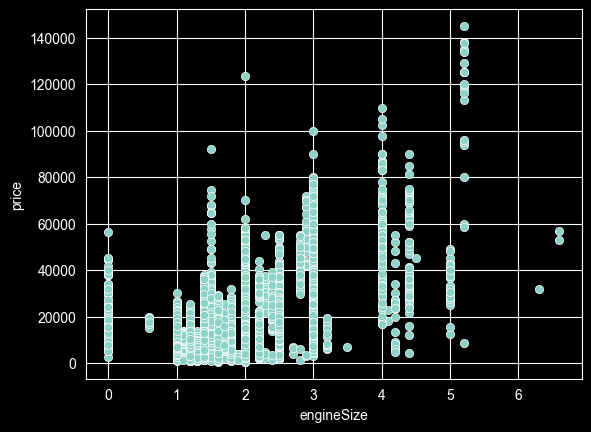

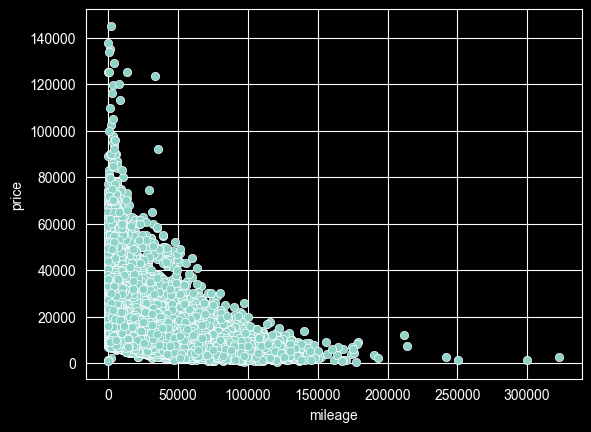

In [231]:
# numerical (most related)
sns.scatterplot(x=df['engineSize'], y=df['price'])
plt.show()

sns.scatterplot(x=df['mileage'], y=df['price'])
plt.show()

In [232]:
#categorical
print(df.groupby('model')['price'].mean().sort_values(ascending=False))
print("------------")
print(df.groupby('Make')['price'].mean().sort_values(ascending=False))
print("------------")
print(df.groupby('fuelType')['price'].mean().sort_values(ascending=False))
print("------------")
print(df.groupby('transmission')['price'].mean().sort_values(ascending=False))

model
R8            97257.080000
X7            69878.187500
8 Series      64424.875000
Q8            59598.133333
California    57565.500000
                  ...     
Getz           1927.500000
Streetka       1924.500000
Amica          1750.000000
Fox            1733.500000
Accent         1295.000000
Name: price, Length: 145, dtype: float64
------------
Make
audi       22894.679872
BMW        22727.820273
vw         16837.325011
skoda      14292.749382
Hyundai    12806.737070
toyota     12504.774279
Ford       12279.505885
Name: price, dtype: float64
------------
fuelType
Hybrid      19067.922073
Diesel      18885.788116
Other       17414.302885
Electric    17374.600000
Petrol      14743.939671
Name: price, dtype: float64
------------
transmission
Semi-Auto    23493.355456
Automatic    21373.580206
Other        14571.000000
Manual       12543.124548
Name: price, dtype: float64


Based on the analysis of both categorical features (groupby mean) and numerical features (correlation matrix), we can conclude the following :

engineSize (strong positive correlation: 0.63)

year (moderate positive correlation: 0.52)

mileage (moderate negative correlation: -0.43)

model (very strong variation in average price across different car models)

transmission (large differences in average price across categories)

Make (strong variation in average price between brands)


 Overall, engineSize,model, transmission, and Make show the strongest relationship with price, followed by year and mileage.

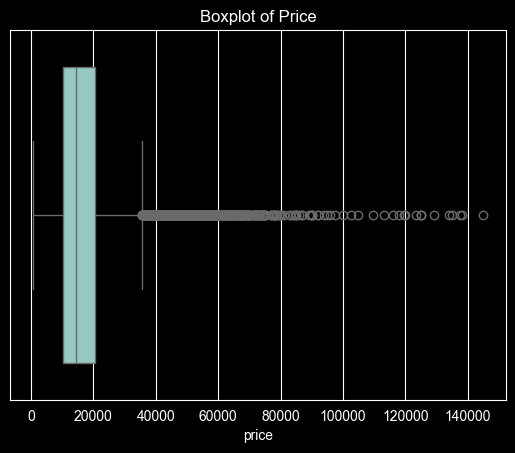

In [233]:
#Outlier Detection

sns.boxplot(x=df['price'])
plt.title("Boxplot of Price")
plt.show()

# Task 2 : Data Preprocessing

**step 0 : Train & Test Split**

We split the data **before any preprocessing** to prevent data leakage.
Data leakage means the model sees test data during training, which gives fake good results.
All preprocessing steps will be fit on train only, then applied to test using the same values.

In [234]:
# Drop rows where price is missing before splitting (no target = useless row)
df_model = df.dropna(subset=['price']).copy()

train, test = train_test_split(df_model, test_size=0.2, random_state=1)

print(f'Train: {train.shape}')
print(f'Test: {test.shape}')

Train: (55051, 10)
Test: (13763, 10)


In [235]:
train_clean = train.copy()
test_clean  = test.copy()

**step 1 : Handling missing values**
1. Before splitting, rows with missing values in the target variable (price) were dropped, since the model cannot be trained without a target value
2. Numerical features (year, mileage, tax, mpg, engineSize) were filled using the median calculated from the training data, as it is more robust to outliers
3. Categorical features (transmission, fuelType, Make) were filled using the mode from the training set
    - Text normalization was applied to categorical features by removing extra spaces and converting all values to lowercase
4. Next, we fill missing values in 'model' using group-wise imputation:
    - for each 'Make', we fill with the most frequent 'model' in that group
        - Missing values in the model column were handled using group-wise imputation:
            * For each Make, missing model values were filled with the most frequent model within that group (calculated from the training data).
            * For the test set, the same mapping from the training data was applied.

In [236]:
# Compute median from train only, apply to both
numerical_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
for col in numerical_cols:
    train_median = train_clean[col].median()
    train_clean[col]= train_clean[col].fillna(train_median)
    test_clean[col]= test_clean[col].fillna(train_median)

In [237]:
categorical_cols = ['transmission', 'fuelType', 'Make']
for col in categorical_cols:
    train_mode = train_clean[col].mode()[0]
    train_clean[col] = train_clean[col].fillna(train_mode)
    test_clean[col]  = test_clean[col].fillna(train_mode)
    # normalize text
    train_clean[col] = train_clean[col].str.strip().str.lower()
    test_clean[col]  = test_clean[col].str.strip().str.lower()

#Handeling nulls in model columns
# normalize text
train_clean['model'] = train_clean['model'].str.strip().str.lower()
test_clean['model']  = test_clean['model'].str.strip().str.lower()

# get mode per Make
model_mode_per_make = train_clean.groupby('Make')['model'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
)

# fill train
train_clean['model'] = train_clean.groupby('Make')['model'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)

# fill test
test_clean['model'] = test_clean['model'].fillna(
    test_clean['Make'].map(model_mode_per_make)
)

# fallback
train_clean['model'] = train_clean['model'].fillna('unknown')
test_clean['model']  = test_clean['model'].fillna('unknown')

train_clean.isnull().sum()
test_clean.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

**step 2 : Detect and handle outliers**

In [238]:
train_clean[numerical_cols].describe().round(2)

,year,mileage,tax,mpg,engineSize
count,55051.00,55051.00,55051.00,55051.00,55051.00
mean,2017.07,22953.76,118.31,55.85,1.63
std,2.05,20912.88,62.85,16.89,0.54
min,1996.00,1.00,0.00,0.30,0.00
25%,2016.00,7736.00,125.00,47.90,1.20
50%,2017.00,17554.50,145.00,55.40,1.60
75%,2019.00,31591.00,145.00,62.80,2.00
max,2020.00,323000.00,580.00,470.80,6.60


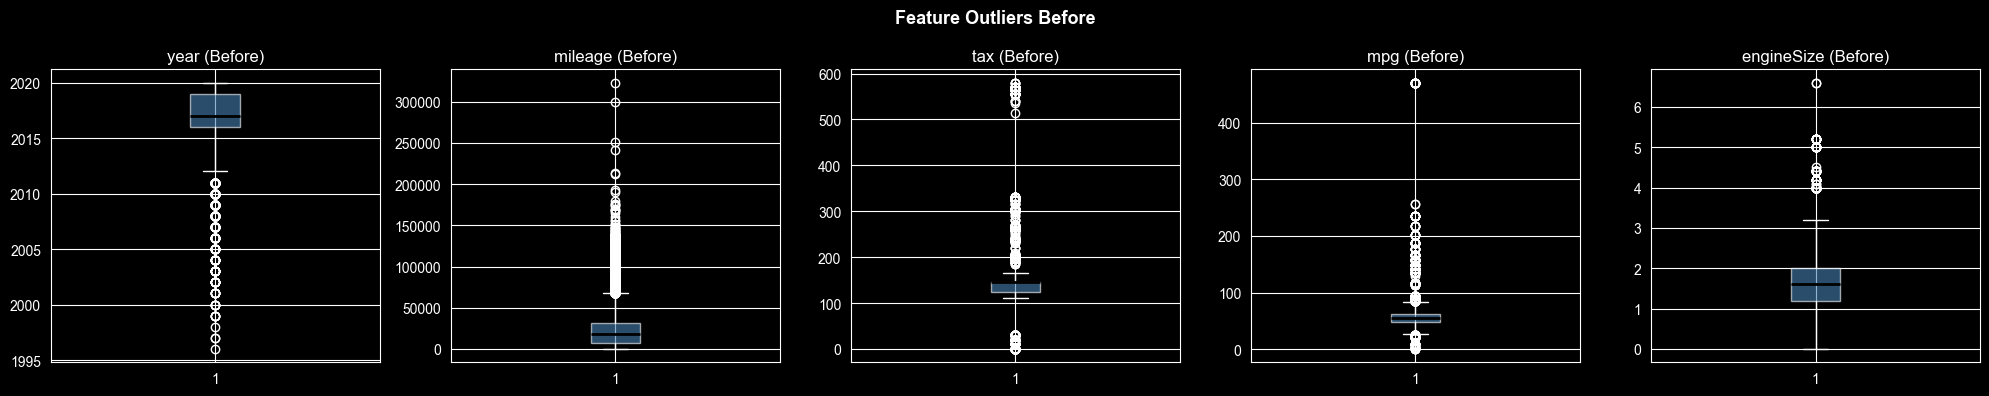

In [239]:
# Before handling
fig_feat, axes_feat = plt.subplots(1, 5, figsize=(20, 4))

for i, col in enumerate(numerical_cols):
    axes_feat[i].boxplot(train_clean[col], patch_artist=True,
                         boxprops=dict(facecolor='steelblue', alpha=0.6),
                         medianprops=dict(color='black', linewidth=2))
    axes_feat[i].set_title(f'{col} (Before)')

plt.suptitle('Feature Outliers Before', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [240]:
# Handling: IQR + Winsorization
for col in numerical_cols:
    Q1    = train_clean[col].quantile(0.25)
    Q3    = train_clean[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = train_clean[(train_clean[col] < lower) | (train_clean[col] > upper)]
    print(f'{col}: {len(outliers)} outliers bounds [{lower:.2f}, {upper:.2f}]')
    train_clean[col] = train_clean[col].clip(lower=lower, upper=upper)
    test_clean[col] = test_clean[col].clip(lower=lower, upper=upper)

year: 922 outliers bounds [2011.50, 2023.50]
mileage: 2445 outliers bounds [-28046.50, 67373.50]
tax: 15895 outliers bounds [95.00, 175.00]
mpg: 788 outliers bounds [25.55, 85.15]
engineSize: 241 outliers bounds [-0.00, 3.20]


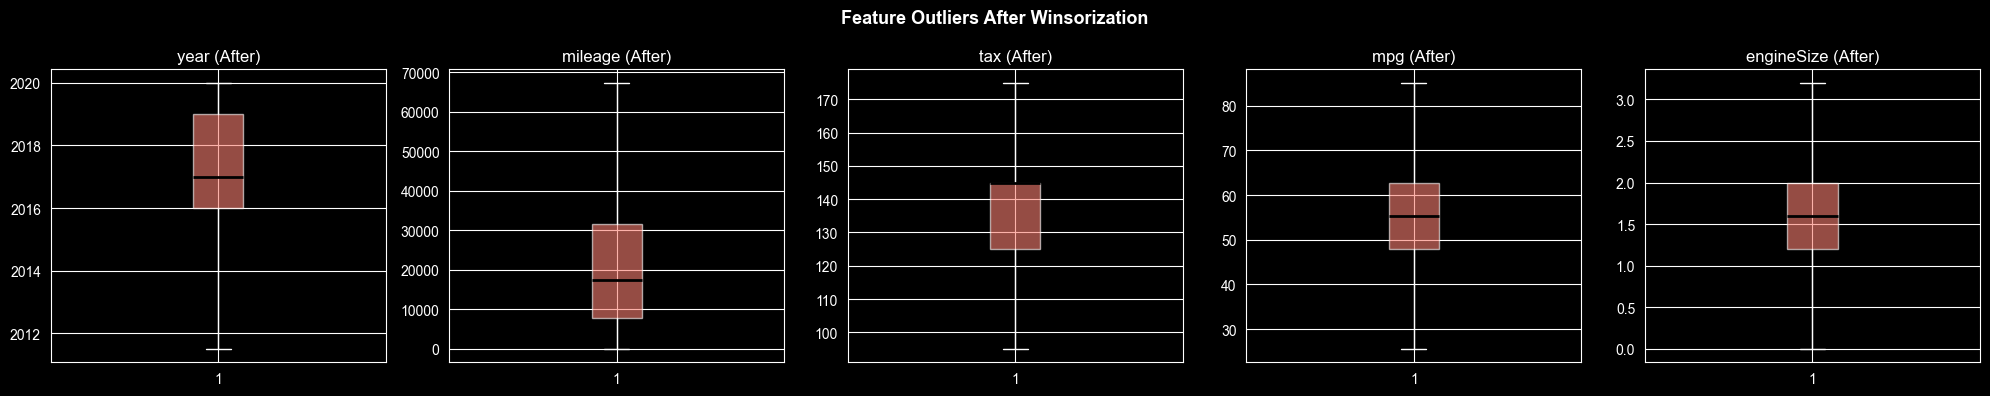

In [241]:
# After
fig_feat2, axes_feat2 = plt.subplots(1, 5, figsize=(20, 4))

for i, col in enumerate(numerical_cols):
    axes_feat2[i].boxplot(train_clean[col], patch_artist=True,
                          boxprops=dict(facecolor='salmon', alpha=0.6),
                          medianprops=dict(color='black', linewidth=2))
    axes_feat2[i].set_title(f'{col} (After)')

plt.suptitle('Feature Outliers After Winsorization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

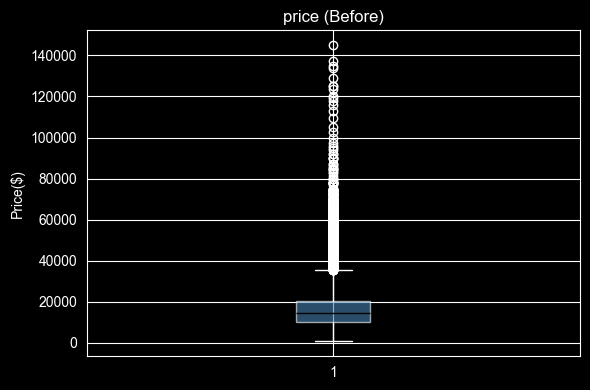

In [242]:
plt.figure(figsize=(6, 4))
plt.boxplot(train_clean['price'], patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6),
            medianprops=dict(color='black', linewidth=1))
plt.title('price (Before)')
plt.ylabel('Price($)')
plt.tight_layout()
plt.show()

**Inspect outliers in the target column (price)**

We check the price column separately since it is the target variable.
Outliers in the target distort what the model learns, so we inspect them before deciding how to handle them.

In [243]:
# Compute price bounds from train only
Q1    = train_clean['price'].quantile(0.25)
Q3    = train_clean['price'].quantile(0.75)
IQR   = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

price_outliers = train_clean[(train_clean['price'] < lower) | (train_clean['price'] > upper)]
print(f'Price Outliers : {len(price_outliers)}')

# We only drop from train.Test stays as it is (we never modify test labels)
length_before = len(train_clean)
train_clean = train_clean[(train_clean['price'] >= lower) & (train_clean['price'] <= upper)]
print(f'Rows dropped: {length_before - len(train_clean)}')
print(f'Rows after  : {len(train_clean)}')

Price Outliers : 2035
Rows dropped: 2035
Rows after  : 53016


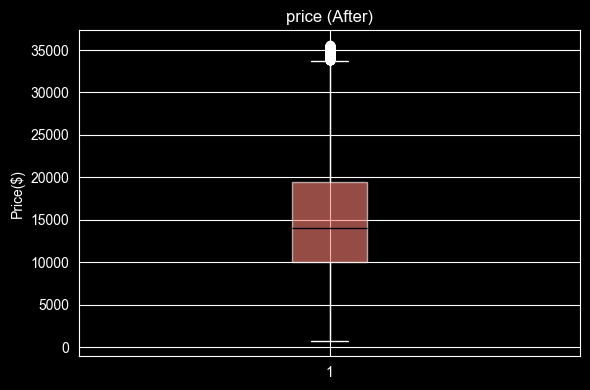

In [244]:
plt.figure(figsize=(6, 4))
plt.boxplot(train_clean['price'], patch_artist=True,
            boxprops=dict(facecolor='salmon', alpha=0.6),
            medianprops=dict(color='black', linewidth=1))
plt.title('price (After)')
plt.ylabel('Price($)')
plt.tight_layout()
plt.show()

**step 3 : Encoding Categorical columns**

In [245]:
cat_cols_to_encode = ['model', 'transmission', 'fuelType', 'Make']

for col in cat_cols_to_encode:
    print(f"{col}: {train_clean[col].nunique()}")

model: 135
transmission: 4
fuelType: 5
Make: 7


**Label Encoding :**
Label Encoding was applied to the high-cardinality feature 'model' with additional handling for unseen values

In [246]:
le = LabelEncoder()
# fit train
train_clean['model'] = le.fit_transform(train_clean['model'])
# handle unseen values in test
test_clean['model'] = test_clean['model'].apply(
    lambda x: x if x in le.classes_ else 'unknown'
)
# add 'unknown' to classes
le.classes_ = np.append(le.classes_, 'unknown')
# transform test
test_clean['model'] = le.transform(test_clean['model'])
train_clean.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
70471,51,2017.0,7169.0,manual,18610.0,petrol,145.0,57.7,1.2,hyundai
58577,21,2017.0,6388.0,manual,26850.0,petrol,95.0,69.0,1.0,toyota
8373,11,2015.0,13650.0,manual,37314.0,diesel,145.0,55.4,2.0,audi
11672,124,2017.0,18698.0,semi-auto,41384.0,diesel,145.0,55.4,2.0,bmw
20801,1,2017.0,13000.0,manual,28706.0,petrol,125.0,52.3,1.5,bmw


**One-Hot Encoding :**

We use One-Hot Encoding for 'transmission', 'fuelType', and 'Make', because they have a small number of categories and no natural order.

In [247]:
cat_cols = ['transmission', 'fuelType', 'Make']
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# fit train
train_ohe = ohe.fit_transform(train_clean[cat_cols])
# transform test
test_ohe = ohe.transform(test_clean[cat_cols])

ohe_cols = ohe.get_feature_names_out(cat_cols)
train_ohe_df = pd.DataFrame(train_ohe, columns=ohe_cols, index=train_clean.index)
test_ohe_df  = pd.DataFrame(test_ohe, columns=ohe_cols, index=test_clean.index)

# drop original categorical columns
train_clean = train_clean.drop(columns=cat_cols)
test_clean  = test_clean.drop(columns=cat_cols)
# concat new encoded columns
train_clean = pd.concat([train_clean, train_ohe_df], axis=1)
test_clean  = pd.concat([test_clean, test_ohe_df], axis=1)
train_clean.head()

,model,year,price,mileage,tax,mpg,engineSize,transmission_automatic,transmission_manual,transmission_other,...,fuelType_hybrid,fuelType_other,fuelType_petrol,Make_audi,Make_bmw,Make_ford,Make_hyundai,Make_skoda,Make_toyota,Make_vw
70471,51,2017.0,7169.0,18610.0,145.0,57.7,1.2,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
58577,21,2017.0,6388.0,26850.0,95.0,69.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8373,11,2015.0,13650.0,37314.0,145.0,55.4,2.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
11672,124,2017.0,18698.0,41384.0,145.0,55.4,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
20801,1,2017.0,13000.0,28706.0,125.0,52.3,1.5,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


**step 4 : Scale numerical features**

**We apply StandardScaler to numerical features: (year, mileage, tax, mpg, engineSize, model)**, because KNN depends on distance calculations

In [248]:
# Fit on train only, apply to both
scale_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'model']
scaler     = StandardScaler()

train_clean[scale_cols] = scaler.fit_transform(train_clean[scale_cols])
test_clean[scale_cols] = scaler.transform(test_clean[scale_cols])

print('Train After scaling:')
print(train_clean[scale_cols].describe().round(2))

Train After scaling:
           year   mileage       tax       mpg  engineSize     model
count  53016.00  53016.00  53016.00  53016.00    53016.00  53016.00
mean      -0.00      0.00      0.00     -0.00        0.00     -0.00
std        1.00      1.00      1.00      1.00        1.00      1.00
min       -3.03     -1.25     -1.61     -2.83       -3.31     -1.40
25%       -0.57     -0.79     -1.61     -0.67       -0.81     -0.78
50%       -0.03     -0.28      0.48     -0.05        0.03     -0.23
75%        1.06      0.53      0.48      0.64        0.86      0.65
max        1.61      2.47      1.73      2.72        3.36      2.08


In [249]:
x_train = train_clean.drop(columns=['price'])
y_train = train_clean['price']

x_test  = test_clean.drop(columns=['price'])
y_test  = test_clean['price']

print(f'x_train : {x_train.shape}')
print(f'x_test  : {x_test.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test  : {y_test.shape}')

x_train : (53016, 22)
x_test  : (13763, 22)
y_train : (53016,)
y_test  : (13763,)


## Preprocessing Summary

| Step               | Action                                                                                                                                                                                                                                                   | Why                                                                                                                                          |
|--------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|----------------------------------------------------------------------------------------------------------------------------------------------|
| **Split**          | 80% train, 20% test after dropping missing target values                                                                                                                                                                                                 | Ensures valid training data and prevents data leakage                                    |
| **Missing Values** | Drop rows with missing price before split; fill categorical features (Make, transmission, fuelType) with Mode; fill model using group-wise imputation (per Make); fill numerical features with Median; apply fallback value for remaining missing values | All statistics computed from train only, then applied to test to avoid data leakage |
| **Outliers**       | Apply IQR-based Winsorization on feature columns using bounds from train; remove outliers in price from train only                                                                                                                                       | Prevents extreme values from affecting the model while preserving test data integrity                                  |
| **Encoding**       | Apply Label Encoding to model with handling for unseen values & One-Hot for transmission, fuelType, Make                                                                                     | Label Encoding avoids high dimensionality for model, while One-Hot Encoding preserves category independence for low-cardinality features                                            |
| **Scaling**        | Apply StandardScaler to numerical columns (year, mileage, tax, mpg, engineSize, model); exclude price                                                                                                                                                    | Normalizes feature scales to improve model performance; fitted on train only                                     |

## Task 3 : Create Two Target Variables

A. Regression Target (Linear Regression)



In [250]:
# set the price column as my target
y = df['price']
y


0        12500.0
1        16500.0
2        11000.0
3        16800.0
4        17300.0
          ...   
72430     8680.0
72431     7830.0
72432     6830.0
72433    13994.0
72434    15999.0
Name: price, Length: 72435, dtype: float64

B. Classification Target (KNN)

In [251]:
# divide data to three categorical (cheap, Moderate, Expensive)
low_threshold = train_clean['price'].quantile(0.33)
high_threshold = train_clean['price'].quantile(0.66)

conditions = [
    train_clean['price'] <= low_threshold,
    train_clean['price'] >= high_threshold
]

choices = ['cheap', 'expensive']

train_clean['price_cat'] = np.select(conditions, choices, default='moderate')

train_clean['price_cat'].value_counts()

#show original data
train_clean.head()


,model,year,price,mileage,tax,mpg,engineSize,transmission_automatic,transmission_manual,transmission_other,...,fuelType_other,fuelType_petrol,Make_audi,Make_bmw,Make_ford,Make_hyundai,Make_skoda,Make_toyota,Make_vw,price_cat
70471,-0.077282,-0.028732,7169.0,-0.223458,0.477991,0.168098,-0.806297,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,cheap
58577,-0.857117,-0.028732,6388.0,0.232110,-1.611468,1.220318,-1.223170,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,cheap
8373,-1.117062,-1.119313,13650.0,0.810637,0.477991,-0.046070,0.861197,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,moderate
11672,1.820317,-0.028732,18698.0,1.035657,0.477991,-0.046070,0.861197,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,expensive
20801,-1.377007,-0.028732,13000.0,0.334724,-0.357793,-0.334732,-0.180986,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,moderate


Decide the thresholds (price boundaries) for each category & how many cars in each category:

In [252]:
print("Threshold 1 (Low): ",low_threshold)
print("Threshold 2 (High): ",high_threshold)

# show threshold for each category

print ("The price boundaries: \n" ,"any price lesser than " , low_threshold , " It is considered cheap")
print (" any price greater than " , high_threshold , " It is considered expensive")
print (" any price between " , high_threshold , " and " , low_threshold ," It is considered moderate \n")

# Show how many cars fall into each category after splitting.

print(train_clean['price_cat'].value_counts())

Threshold 1 (Low):  11057.0
Threshold 2 (High):  17450.0
The price boundaries: 
 any price lesser than  11057.0  It is considered cheap
 any price greater than  17450.0  It is considered expensive
 any price between  17450.0  and  11057.0  It is considered moderate 

price_cat
expensive    18042
cheap        17496
moderate     17478
Name: count, dtype: int64


Justify my thresholds — use the data distribution to support your decision

To define the thresholds for the price categories (Cheap, Moderate, and Expensive), I analyzed the price distribution using the percentiles (Quantiles) of the dataset. I chose the 33rd and 66th percentiles as my boundaries for the following reasons:

1.  Data Balance: Using quantiles ensures that each category contains approximately one-third of the total cars. This prevents the KNN model from being biased toward a specific class that might have more data than others (Class Imbalance problem).
2.  Statistical Evidence: Based on the EDA and the describe() function, the 33rd percentile represents the lower-end market, while the 66th percentile marks the transition to premium/high-end cars.
3.  Threshold Values: The calculated boundaries are:
* Cheap: Prices $\le$ 11125
* Moderate: Prices between 11125 and 17480
* Expensive: Prices $>$ 17480

# Task 4: Linear Regression Model
We will train a Linear Regression model to predict the car price.

In [253]:
#Training model
model = LinearRegression()
model.fit(x_train, y_train)
#prediction
y_pred = model.predict(x_test)

In [254]:
#Evaluation techniques
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2783.7792266365113
MSE: 21559162.481812637
RMSE: 4643.184519466423
R2 Score: 0.7481749926251321


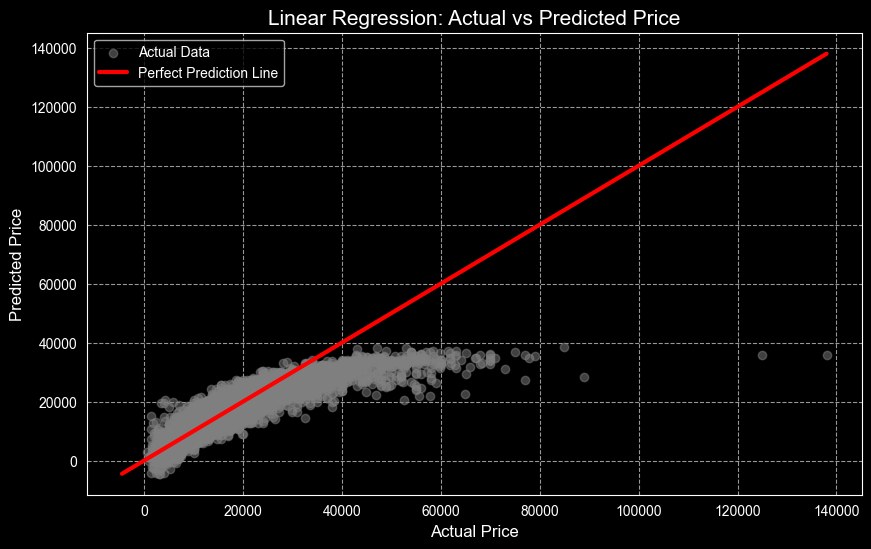

In [255]:
plt.figure(figsize=(10, 6))

# Plot actual vs predicted points
plt.scatter(y_test, y_pred, color='gray', alpha=0.5, label='Actual Data')

# line range (perfect prediction line)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))

plt.plot(
    np.linspace(min_val, max_val, 100),
    np.linspace(min_val, max_val, 100),
    color='red',
    linewidth=3,
    label='Perfect Prediction Line'
)

plt.title('Linear Regression: Actual vs Predicted Price', fontsize=15)
plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

##  tring to improve model based on correlation
The most positively correlated features are: engineSize, year

The most negatively correlated features are: mileage, mpg

In [256]:
#trying to increase r2 score
train_clean['age'] = 2026 - train_clean['year']
train_clean['engine_per_year'] = train_clean['engineSize'] * train_clean['year']
train_clean['mileage_per_engine'] = train_clean['mileage'] / train_clean['engineSize']
train_clean['age_mileage'] = train_clean['age'] * train_clean['mileage']

X = train_clean.drop(['price', 'price_cat'], axis=1)
y = train_clean['price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2161.038842327937
MSE: 8328458.948880346
RMSE: 2885.906954300562
R2: 0.827419880523403


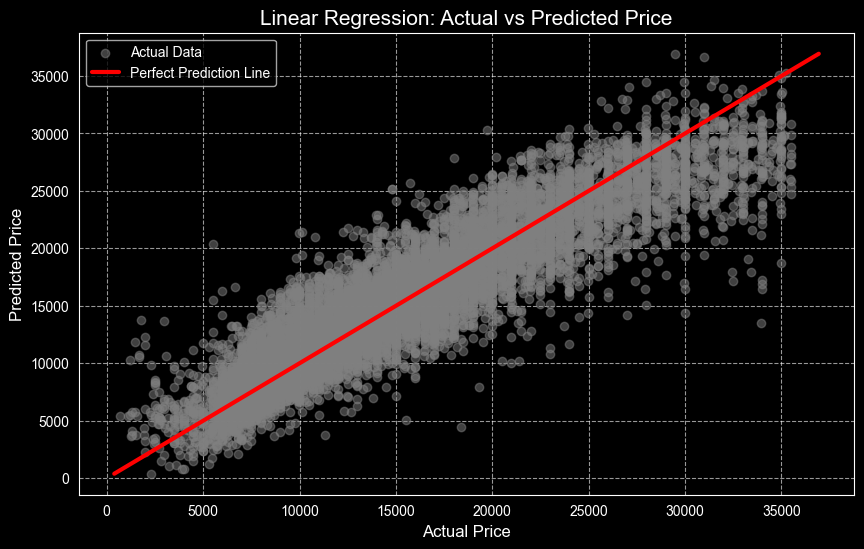

In [257]:
plt.figure(figsize=(10, 6))

# Plot actual vs predicted points
plt.scatter(y_test, y_pred, color='gray', alpha=0.5, label='Actual Data')

# line range (perfect prediction line)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))

plt.plot(
    np.linspace(min_val, max_val, 100),
    np.linspace(min_val, max_val, 100),
    color='red',
    linewidth=3,
    label='Perfect Prediction Line'
)

plt.title('Linear Regression: Actual vs Predicted Price', fontsize=15)
plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### Conclusion
R² increased with score from 81% to 82% with using correlated features